# Training

The training loop is straightforward:

1. Sample a real image $x_0$
2. Sample a random timestep $t$
3. Sample noise $\varepsilon \sim \mathcal{N}(0, \mathbf{I})$
4. Compute $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \varepsilon$
5. Predict $\varepsilon_\theta(x_t, t)$
6. Minimize $\|\varepsilon - \varepsilon_\theta\|^2$

In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

%run 02_unet.ipynb   # brings in UNet, Block, sinusoidal_embedding

input:  torch.Size([4, 1, 28, 28])
output: torch.Size([4, 1, 28, 28])


## Noise Schedule

In [14]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

T = 1000
betas      = torch.linspace(1e-4, 0.02, T).to(device)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def forward(x0, t):
    ab  = alpha_bars[t].view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    xt  = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    return xt, eps

using mps


## Data

In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # scale to [-1, 1]
])

dataset    = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

## Training Loop

epoch  1  loss 0.1008


epoch  2  loss 0.0406


epoch  3  loss 0.0355


epoch  4  loss 0.0327


epoch  5  loss 0.0308


epoch  6  loss 0.0295


epoch  7  loss 0.0287


epoch  8  loss 0.0282


epoch  9  loss 0.0276


epoch 10  loss 0.0269


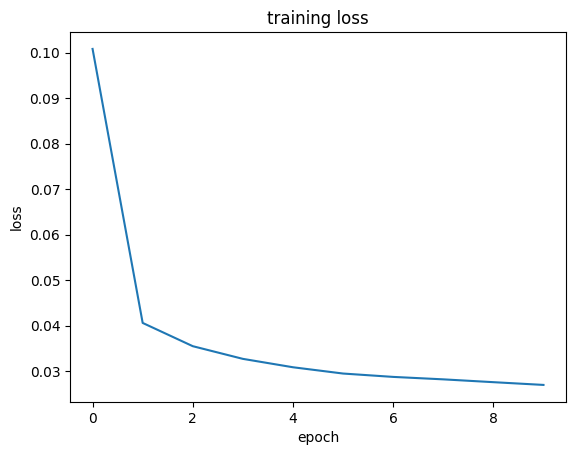

In [16]:
model     = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loss_fn   = nn.MSELoss()

epochs = 10
losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f'epoch {epoch+1}/{epochs}', leave=False)
    for x0, labels in pbar:
        x0         = x0.to(device)
        labels     = labels.to(device)
        t          = torch.randint(0, T, (x0.shape[0],), device=device)
        xt, eps    = forward(x0, t)
        eps_pred   = model(xt, t, labels)
        loss       = loss_fn(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg = epoch_loss / len(dataloader)
    losses.append(avg)
    print(f'epoch {epoch+1:2d}  loss {avg:.4f}')

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training loss')
plt.show()

## Save Checkpoint

In [17]:
torch.save(model.cpu().state_dict(), '../data/unet_mnist.pt')
model.to(device)

UNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
  )
  (label_emb): Embedding(10, 128)
  (enc1): Block(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (norm2): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (act): ReLU()
    (time_proj): Linear(in_features=128, out_features=32, bias=True)
  )
  (enc2): Block(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (act): ReLU()
    (time_proj): Linear(in_features=128, out_features=64, bias=True)
  )